#### Load packages

In [73]:
import numpy as np 
import pandas as pd
from nilearn import signal, image
from nilearn.input_data import NiftiMasker, NiftiLabelsMasker
import nibabel as nib 
import matplotlib.pyplot as plt 
import os
from scipy.signal import welch
from tqdm import tqdm 
from nilearn import plotting
from tqdm import tqdm

#### Load data

In [74]:
# Load subject information
X_my_SZ = pd.read_csv('/n02dat01/users/ypwang/SCZ/SCZ_202310/Data/Info/n00_Siemens_sites&cov_info.csv').iloc[296:, :]
X_my_NC = pd.read_csv('/n02dat01/users/ypwang/SCZ/SCZ_202310/Data/Info/n00_Siemens_sites&cov_info.csv').iloc[0:296, :]

# Extract subject IDs
subjects_scz = X_my_SZ.iloc[:, 0]   # 319 subjects
subjects_hc = X_my_NC.iloc[:, 0]    # 296 subjects

# Load atlas and create masker
bn_atlas = nib.load("/n02dat01/users/lchai/Nmodel/CPC_ML_tutorial-master/BN_Atlas_246_3mm.nii.gz")
bn_masker = NiftiLabelsMasker(labels_img=bn_atlas, standardize=False)
bn_masker.fit()

NiftiLabelsMasker(labels_img=<nibabel.nifti1.Nifti1Image object at 0x7f28484b34c0>)

#### Calculate fALFF

Calculate for each subject

In [75]:
# Define function to calculate fALLF
def calculate_falff(fmri_file, masker, output_dir, subject_id):
    # Load fMRI data
    img = nib.load(fmri_file)

    # Apply brainnetome masker
    time_series = masker.transform(img)             # (230, 246) --> (time series numb., BNA regions)

    # Calculate the power spectrum density (PSD)
    f, psd = welch(time_series, axis=0)

    # Calculate the total power in the low frequency range (0.01-0.1 Hz)
    low_freq_power = np.sum(psd[(f >= 0.01) & (f <= 0.1)], axis=0)   
    #low_freq_power = np.sum(psd[(f >= 0.01) & (f <= 0.08)], axis=0)         # Frequency range used by the Nature Medicine paper 

    # Calculate the toal power acorss the entire frequency spectrum
    total_power = np.sum(psd, axis=0)

    # Calculate fALFF
    fALFF = low_freq_power / total_power        # This is a standard approach for calculating fALFF

    # Create image with the fALFF values
    fALFF_img = masker.inverse_transform(fALFF)

    # Save the fALFF image for the subject
    output_filename = f"{subject_id}_fALFF_01Hz.nii.gz"
    #output_filename = f"{subject_id}_fALFF_008Hz.nii.gz"
    nib.save(fALFF_img, os.path.join(output_dir, output_filename))

# Output directory
output_dir_scz = '/n01dat01/camilla/973/fALFF/fALFF_scz/01Hz'
#output_dir_scz = '/n01dat01/camilla/973/fALFF/fALFF_scz/008Hz'
output_dir_hc = '/n01dat01/camilla/973/fALFF/fALFF_hc/01Hz'
#output_dir_hc = '/n01dat01/camilla/973/fALFF/fALFF_hc/008Hz'

# Loop through scz subjects
for sub in tqdm(subjects_scz):
    # load time series data
    fmri_file = f"/n03dat01/sz_fmri/973_DATA_ALL/dataUseT1/{sub}/s6fdGRwrabrant_4D.nii.gz"
    # Calculate fALFF data by calling function
    calculate_falff(fmri_file, bn_masker, output_dir_scz, sub)

# Loop through hc subjects
for sub in tqdm(subjects_hc):
    fmri_file = f"/n03dat01/sz_fmri/973_DATA_ALL/dataUseT1/{sub}/s6fdGRwrabrant_4D.nii.gz"
    calculate_falff(fmri_file, bn_masker, output_dir_hc, sub)

print("fALFF calculations completed for all subjects!")

  0%|          | 0/319 [00:00<?, ?it/s]/share/home/camilla/anaconda3/envs/env_py38/lib/python3.8/site-packages/nilearn/_utils/niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
/share/home/camilla/anaconda3/envs/env_py38/lib/python3.8/site-packages/scipy/signal/_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 230, using nperseg = 230
  warnings.warn('nperseg = {0:d} is greater than input length '
100%|██████████| 296/296 [39:23<00:00,  7.98s/it]

fALFF calculations completed for all subjects!


#### Check values for fALFF files

In [76]:
import nibabel as nib
import numpy as np

file_path = '/n01dat01/camilla/973/fALFF/fALFF_scz/01Hz/SZ_01_0012_fALFF_01Hz.nii.gz'
img = nib.load(file_path)
data = img.get_fdata()

print('Shape of array:', data.shape)
print('Min:', np.min(data))
print('Max:', np.max(data))
print('Mean:', np.mean(data))

print(data)

Shape of array: (61, 73, 61)
Min: 0.0
Max: 0.9113922715187073
Mean: 0.09955571834045349
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  

#### Visualise fALFF values on atlas

<Figure size 800x600 with 0 Axes>

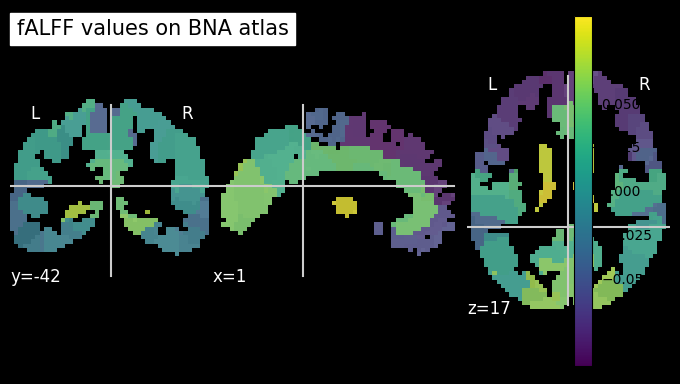

In [62]:
import numpy as np 
import nibabel as nib 
import matplotlib.pyplot as plt 
from nilearn import plotting
from nilearn.input_data import NiftiLabelsMasker

# Load fALFF image for a subject
fALFF_img = nib.load('/n01dat01/camilla/973/fALFF/fALFF_hc/01Hz/NC_01_0007_fALFF_01Hz.nii.gz')

# Load BNA atlas and create masker
bn_atlas = nib.load("/n02dat01/users/lchai/Nmodel/CPC_ML_tutorial-master/BN_Atlas_246_3mm.nii.gz")
bn_masker = NiftiLabelsMasker(labels_img=bn_atlas, standardize=False)
bn_masker.fit()

# Extract fALFF values
fALFF_data = bn_masker.transform(fALFF_img)

# Plot the fALFF values on the BNA atlas
plt.figure(figsize=(8, 6))
plotting.plot_roi(bn_atlas, bg_img=fALFF_img, cmap='viridis', title='fALFF values on BNA atlas')
img_plot = plt.gca().get_children()[0]
plt.colorbar(img_plot)
plt.show()